# Repeated Games, Cooperation, and the Axelrod Tournament

Alex Ronczewski  
2026-07-16

## Outline

### Prerequisites

-   Notebook 2 of this stream.
-   Basic Python and `numpy` at the COMET-intermediate level.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Explain what repetition changes in a game: a strategy becomes a
    **rule over the whole history** of play.
2.  Implement the classic repeated-game strategies: always defect,
    **tit-for-tat**, **grim trigger**, and **win-stay-lose-shift**.
3.  Explain why cooperation breaks when the number of rounds is fixed
    and known, and why an open-ended horizon restores it.
4.  Derive by hand the **continuation probability** above which grim
    trigger makes cooperation self-enforcing.
5.  Run an **Axelrod-style tournament** with the `axelrod` Python
    library and describe what the winning strategies have in common.
6.  State the **folk theorem** informally and explain what it does to
    the question “what will the algorithms play?”.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import axelrod as axl

## 1. The same rival, every morning

Notebook 1 gave the pricing game a firm verdict. Two retailers’
algorithms each post **High** or **Low**; Low strictly dominates; the
only equilibrium is (Low, Low), a price war giving a payoff of 4 to each
player, while (High, High), worth 10 to each is never reached.

That verdict rests on an assumption our own story contradicts: the
algorithms post prices *every morning*, yet Notebook 1 analyzed each
morning as if it were the only one. In reality the same two algorithms
meet daily, with full logs of every price ever posted. If firm 1
undercuts today, firm 2 can undercut tomorrow, and once actions have
consequences beyond the current round, the dominance argument starts to
change.

The object we need is a **repeated game**: the one-shot pricing game
becomes the **stage game**, played over and over, and payoffs accumulate
day by day. The big change is what a strategy is. A strategy stops being
a single action and becomes a **rule that maps the entire history of
play to today’s action**. Notebook 2’s fictitious play is an example of
a rule like that, though it treated the rival as a fixed pattern to
estimate. The rules here face something new: your action today changes
how the rival treats you tomorrow. Retaliation, punishment, and
forgiveness become possible.

The literature on repeated games, and the library we use later, speaks
in **cooperate** and **defect**: in our pricing story, cooperating is
posting High and defecting is undercutting to Low. High = cooperate =
action 0, Low = defect = action 1.

## 2. Strategies as rules over history

A strategy is now a function: it receives the two histories, its own and
its rival’s, and returns today’s action. Here are the five classics,
each a few lines.

In [2]:
A = np.array([[10, 2],
              [12, 4]])       # the stage game from Notebook 1: rows and columns are High, Low
actions = ["High", "Low"]     # High = cooperate (0), Low = defect (1)

def always_low(own, rival):      # the one-shot logic: defect, always
    return 1

def always_high(own, rival):     # unconditional cooperation
    return 0

def tit_for_tat(own, rival):     # start High, then copy the rival's last move
    return rival[-1] if rival else 0

def grim_trigger(own, rival):    # High until the rival ever plays Low, then Low forever
    return 1 if 1 in rival else 0

def win_stay_lose_shift(own, rival):
    if not own:
        return 0
    good_round = rival[-1] == 0  # the rival cooperated, so we earned 10 or 12
    return own[-1] if good_round else 1 - own[-1]

Each of these encodes an attitude. `always_low` is Notebook 1’s
dominance argument on autopilot. It always posts Low. `always_high` is
the same just always posting a high price. `tit_for_tat` opens with
trust and then mirrors: cooperation is answered with cooperation, an
undercut with an immediate undercut, and one round of good behaviour is
enough to be forgiven. `grim_trigger` is maximal deterrence: a single
instance of betrayal and it punishes forever. `win_stay_lose_shift`
ignores revenge entirely and just repeats whatever worked: after a round
where the rival cooperated it keeps its action, after a round where the
rival defected it switches.

A match between two rules is a loop: ask each rule for its action,
append to the histories, repeat, and score each day with the stage-game
matrix.

In [3]:
def play_match(strategy1, strategy2, days):
    h1, h2 = [], []
    for t in range(days):
        a = strategy1(h1, h2)
        b = strategy2(h2, h1)   # each rule sees (its own history, its rival's history)
        h1.append(a)
        h2.append(b)
    score1 = sum(A[a, b] for a, b in zip(h1, h2))
    score2 = sum(A[b, a] for a, b in zip(h1, h2))
    return h1, h2, score1, score2

for s1, s2, label in [(always_low, always_low, "always Low  vs always Low "),
                      (tit_for_tat, always_low, "tit-for-tat vs always Low "),
                      (tit_for_tat, tit_for_tat, "tit-for-tat vs tit-for-tat")]:
    h1, h2, sc1, sc2 = play_match(s1, s2, days=20)
    print(f"{label}: {sc1:3} vs {sc2:3} over 20 days")

always Low  vs always Low :  80 vs  80 over 20 days
tit-for-tat vs always Low :  78 vs  88 over 20 days
tit-for-tat vs tit-for-tat: 200 vs 200 over 20 days

Twenty days of price war pay 80. Tit-for-tat against `always_low` earns
78: it gets exploited exactly once, on day 0, and defends itself from
then on. Opening with trust cost it that one round and nothing more. And
two tit-for-tats earn 200 each, 10 per day: the (High, High) outcome
Notebook 1 ruled out for players choosing one action is sustainable for
rules playing many rounds.

Below we run four matches and draw each as a timeline, one row per
player, one column per day, colour showing the price posted. The last
two matches include a strategy that *slips*: it plays tit-for-tat (or
win-stay-lose-shift) but defects once, on day 10, by accident.

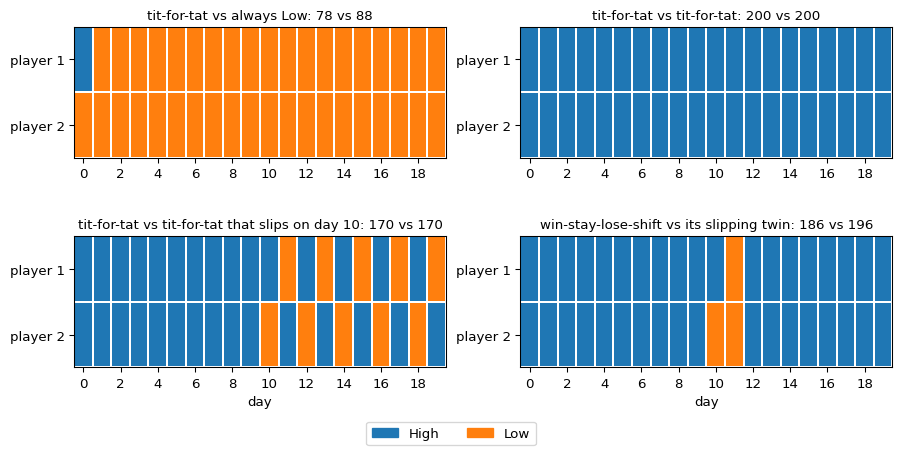

In [4]:
def tit_for_tat_slip(own, rival):    # tit-for-tat, except it slips and plays Low on day 10
    if len(own) == 10:
        return 1
    return tit_for_tat(own, rival)

def wsls_slip(own, rival):           # win-stay-lose-shift with the same day-10 slip
    if len(own) == 10:
        return 1
    return win_stay_lose_shift(own, rival)

matches = [
    (tit_for_tat, always_low, "tit-for-tat vs always Low"),
    (tit_for_tat, tit_for_tat, "tit-for-tat vs tit-for-tat"),
    (tit_for_tat, tit_for_tat_slip, "tit-for-tat vs tit-for-tat that slips on day 10"),
    (win_stay_lose_shift, wsls_slip, "win-stay-lose-shift vs its slipping twin"),
]

action_colors = ["tab:blue", "tab:orange"]
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for ax, (s1, s2, title) in zip(axes.ravel(), matches):
    h1, h2, sc1, sc2 = play_match(s1, s2, days=20)
    ax.pcolormesh(np.array([h1, h2]), cmap=ListedColormap(action_colors), vmin=0, vmax=1,
                  edgecolors="white", linewidth=1.5)
    ax.set_xticks(np.arange(0, 20, 2) + 0.5, range(0, 20, 2))
    ax.set_yticks([0.5, 1.5], ["player 1", "player 2"])
    ax.set_ylim(2, 0)
    ax.set_title(f"{title}: {sc1} vs {sc2}", fontsize=10)
for ax in axes[1]:
    ax.set_xlabel("day")
fig.legend(handles=[Patch(color=c, label=a) for c, a in zip(action_colors, actions)],
           ncols=2, loc="lower center")
fig.subplots_adjust(bottom=0.17, hspace=0.6)
plt.show()

The top row we have already read, the bottom row is more interesting. In
the third panel, one accidental defection between two tit-for-tats
echoes forever: the slipper defects on day 10, the other retaliates on
day 11 just as the slipper returns to High, and the two alternate
exploiting each other, 170 each instead of 200. Tit-for-tat retaliates
and forgives, but it cannot *end a feud it did not start*. In the fourth
panel the same slip between two win-stay-lose-shifts costs two bad days,
and cooperation resumes on day 12. That error correction is why
win-stay-lose-shift, also called Pavlov, beats tit-for-tat in noisy
environments where accidents can occur.

## 3. When do High prices hold together?

Section 2 shows that mutual cooperation *can happen* between the right
rules, but can it be an **equilibrium**? Is there a pair of strategies,
each a best response to the other, that keeps prices High? The answer
depends on how many days are left.

Suppose first that both algorithms know the game lasts exactly 100 days.
Day 100 is then a one-shot pricing game, there is no tomorrow to punish
anything, so both post Low. But if day 100 is Low no matter what,
nothing done on day 99 has consequences, so day 99 is one-shot too: Low.
The same argument continues at day 98, then 97, and the whole game
unravels back to the start. With a fixed, commonly known end date, the
unique equilibrium is a price war from day one. Repetition alone does
not fix our issue.

What rescues cooperation is an *open end*. Suppose that after each day
the game continues with probability $\delta$ and ends with probability
$1 - \delta$. There is now no final day to anchor the unraveling.
Consider both firms running grim trigger, and ask whether either wants
to deviate. Cooperating pays 10 today, and 10 for every day the game
survives:

$$
V_{\text{cooperate}} = 10 + 10\delta + 10\delta^2 + \cdots = \frac{10}{1 - \delta}.
$$

Undercutting pays 12 today, and then triggers permanent punishment, 4
for every surviving day:

$$
V_{\text{deviate}} = 12 + 4\delta + 4\delta^2 + \cdots = 12 + \frac{4\delta}{1 - \delta}.
$$

Cooperation is a best response when
$V_{\text{cooperate}} \ge V_{\text{deviate}}$. Multiply both sides by
$1 - \delta$ and simplify: $10 \ge 12 - 8\delta$, so

$$
\delta \ge \frac{12 - 10}{12 - 4} = \frac{1}{4}.
$$

If there is at least a quarter chance of meeting again tomorrow, grim
trigger against grim trigger is a Nash equilibrium in which the price
war never happens and both firms post High forever. The undercut’s
one-day gain of 2 is simply worth less than the future it destroys.

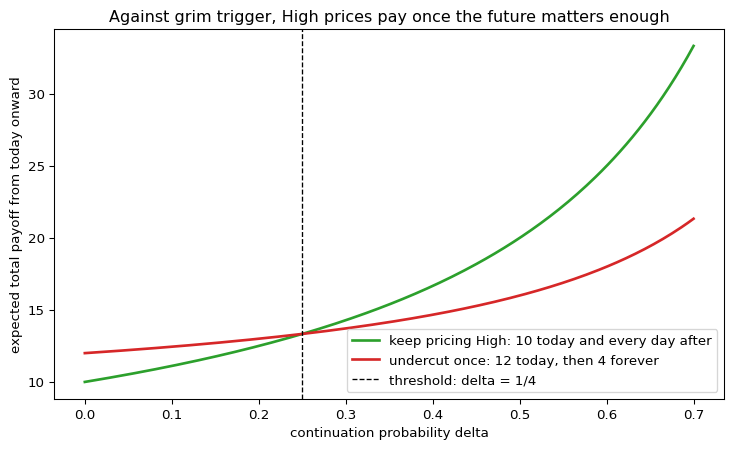

In [5]:
delta = np.linspace(0, 0.7, 200)

plt.figure(figsize=(9, 5))
plt.plot(delta, 10 / (1 - delta), color="tab:green", linewidth=2,
         label="keep pricing High: 10 today and every day after")
plt.plot(delta, 12 + 4 * delta / (1 - delta), color="tab:red", linewidth=2,
         label="undercut once: 12 today, then 4 forever")
plt.axvline(0.25, color="black", linestyle="--", linewidth=1, label="threshold: delta = 1/4")
plt.xlabel("continuation probability delta")
plt.ylabel("expected total payoff from today onward")
plt.title("Against grim trigger, High prices pay once the future matters enough")
plt.legend()
plt.show()

The threshold $\delta \ge (T - R)\,/\,(T - P)$, temptation minus reward
over temptation minus punishment, is the general form of this
calculation. Cooperation survives when the future is long (high
$\delta$), the temptation to cheat is small ($T - R$ = 2 here), and the
punishment hurts ($T - P$ = 8 here). Economists call this mechanism the
**shadow of the future**: the expectation of continued interaction is
what makes today’s good behaviour rational.

> **Cooperation here is collusion**
>
> The words carry positive sentiment: cooperation, trust, forgiveness.
> In this market they mean both firms posting High every day: prices
> held above the competitive level with no contract, no meeting, and no
> message ever exchanged. Competition law calls that tacit collusion,
> and this section’s mathematics is why regulators worry about pricing
> algorithms that meet the same rivals daily. Whether learning
> algorithms find this arrangement on their own is Notebook 4’s
> question. For the average consumer (like you) this is not positive by
> any means.

> **Self-test**
>
> A recession thins the margins: (High, High) now pays 6 to each firm
> instead of 10, while the other cells keep their payoffs. How much
> likelier does “meeting again tomorrow” have to be for grim trigger to
> keep sustaining High prices?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> The threshold is
> $\delta \ge (T - R)/(T - P) = (12 - 6)/(12 - 4) = 3/4$, up from $1/4$.
> Cooperating now only beats the price war by 2 per day while a
> successful undercut still grabs 12, so the future has to be three
> times more certain before patience is worth it. Thin margins make
> collusion fragile, which is one reason price wars break out in periods
> of downturn, the payoff of defecting is more tempting.
>
> </details>

## 4. The Axelrod tournament

So which rule should a firm actually deploy? In 1980 the political
scientist Robert Axelrod answered this empirically: he invited game
theorists to submit programs for the repeated prisoner’s dilemma and
played every program against every other, round-robin. The winner was
the shortest program submitted: tit-for-tat, sent in by Anatol Rapoport.

We rerun the experiment with the `axelrod` Python library, keeping our
pricing payoffs. The field is ten strategies: our five from section 2,
under the library’s names (`Grudger` is grim trigger), plus five
newcomers. **Tit For 2 Tats** retaliates only after two Lows in a row;
**Joss**, from the actual 1980 field, is a tit-for-tat that sneaks in a
Low about 10% of the time; **Tester** opens with a Low and backs off
only if punished; **Alternator** alternates no matter what; **Random**
flips a coin. Every pairing plays 200 days, repeated 10 times to average
out the coin flips.

In [6]:
pricing = axl.Game(r=10, s=2, t=12, p=4)   # our stage game in the library's (R, S, T, P) order

field = [axl.Cooperator(), axl.Defector(), axl.TitForTat(), axl.TitFor2Tats(),
         axl.Grudger(), axl.WinStayLoseShift(), axl.FirstByJoss(),
         axl.SecondByTester(), axl.Alternator(), axl.Random()]

tournament = axl.Tournament(field, game=pricing, turns=200, repetitions=10, seed=42)
results = tournament.play(progress_bar=False)

mean_per_day = {name: np.mean(scores) for name, scores
                in zip(results.players, results.normalised_scores)}
for rank, name in enumerate(results.ranked_names, 1):
    print(f"{rank:2}. {name:22} {mean_per_day[name]:.2f} per day")

 1. Tit For Tat            8.06 per day
 2. Tit For 2 Tats         7.94 per day
 3. Win-Stay Lose-Shift    7.67 per day
 4. Cooperator             7.67 per day
 5. Grudger                7.60 per day
 6. Second by Tester       7.19 per day
 7. Alternator             6.97 per day
 8. Random: 0.5            6.75 per day
 9. First by Joss: 0.9     6.45 per day
10. Defector               6.25 per day

Tit-for-tat wins here too, at just over 8 points a day. Axelrod called a
strategy **nice** if it is never the first to defect. Our field contains
five nice strategies (Cooperator, Tit For Tat, Tit For 2 Tats, Grudger,
Win-Stay Lose-Shift) and five that defect unprovoked, and the ranking
splits perfectly: every nice strategy finishes above every non-nice one.

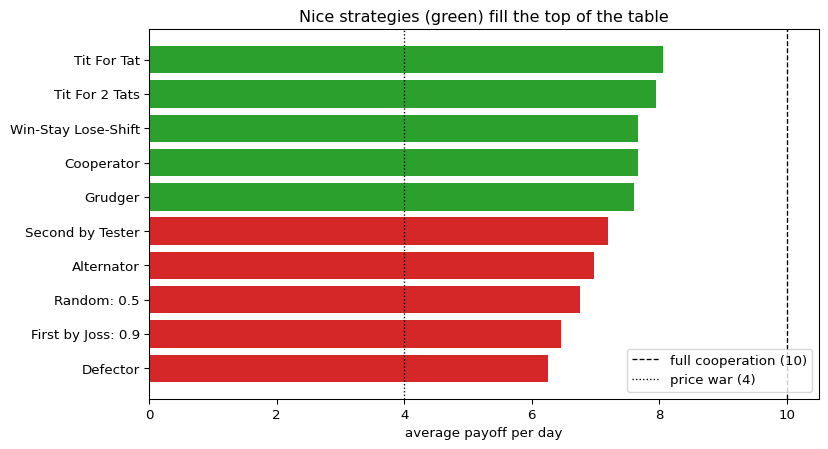

In [7]:
nice = {"Cooperator", "Tit For Tat", "Tit For 2 Tats", "Grudger", "Win-Stay Lose-Shift"}
names = results.ranked_names[::-1]
colors = ["tab:green" if n in nice else "tab:red" for n in names]

plt.figure(figsize=(9, 5))
plt.barh(names, [mean_per_day[n] for n in names], color=colors)
plt.axvline(10, color="black", linestyle="--", linewidth=1, label="full cooperation (10)")
plt.axvline(4, color="black", linestyle=":", linewidth=1, label="price war (4)")
plt.xlabel("average payoff per day")
plt.title("Nice strategies (green) fill the top of the table")
plt.legend(loc="lower right")
plt.show()

At the very bottom sits Defector, playing the stage game’s dominant
action every day. It wins every match it plays, turns every relationship
into a 4-a-day price war, and finishes last.

Here is tit-for-tat’s scoring margin against each rival, match by match:

In [8]:
payoff = np.array(results.payoff_matrix)   # payoff[i, j]: player i's mean per-day score against j
i = results.players.index("Tit For Tat")

print("tit-for-tat's per-day margin over each rival in their own matches:")
for name, margin in zip(results.players, payoff[i] - payoff[:, i]):
    print(f"  vs {name:22} {margin:+.2f}")

tit-for-tat's per-day margin over each rival in their own matches:
  vs Cooperator             +0.00
  vs Defector               -0.05
  vs Tit For Tat            +0.00
  vs Tit For 2 Tats         +0.00
  vs Grudger                +0.00
  vs Win-Stay Lose-Shift    +0.00
  vs First by Joss: 0.9     -0.05
  vs Second by Tester       +0.00
  vs Alternator             -0.05
  vs Random: 0.5            -0.03

Tit-for-tat never outscores anyone: every margin is zero or slightly
negative, and it still won the tournament. It gets rich by making
everyone it meets rich too, while Defector beats everyone and starves.
Axelrod distilled the winners’ traits into four properties: **nice**
(never defect first), **retaliatory** (punish immediately, or strategies
like Tester will farm you), **forgiving** (return to cooperation after
punishing, or one slip becomes the third panel of section 2), and
**clear** (a rival must be able to learn what you reward and punish).

## 5. The folk theorem

Section 3 proved one outcome sustainable: permanent (High, High), held
up by grim trigger, for $\delta \ge 1/4$. A firm can always guarantee
itself at least 4 a day by posting Low, so take *any* pattern of play
giving each firm an average above 4, threaten permanent punishment for
deviating from it, and the same calculation makes it an equilibrium for
patient enough players.

This result is the **folk theorem**: in an infinitely repeated game with
sufficiently patient players, every feasible pair of average payoffs
above each player’s guaranteed minimum can arise in a Nash equilibrium.
Below, the pale region is every average payoff pair the firms could
produce by mixing the four cells over time, and the green region is the
folk theorem’s answer: all of it is equilibrium territory.

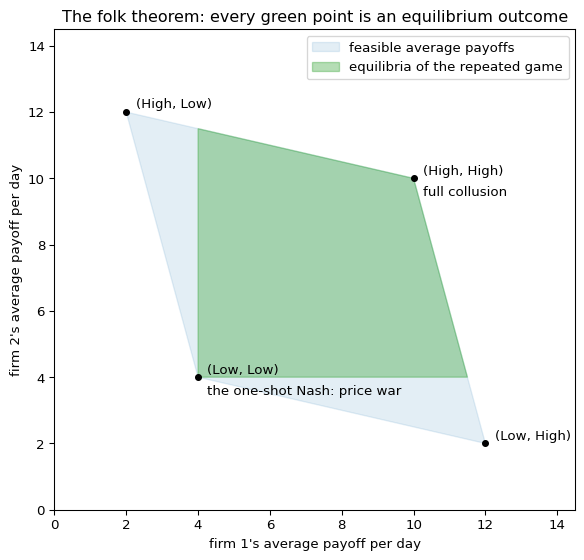

In [9]:
outcomes = {"(High, High)": (10, 10), "(High, Low)": (2, 12),
            "(Low, High)": (12, 2), "(Low, Low)": (4, 4)}

feasible = plt.Polygon([(4, 4), (12, 2), (10, 10), (2, 12)], closed=True,
                       color="tab:blue", alpha=0.12, label="feasible average payoffs")
sustainable = plt.Polygon([(4, 4), (11.5, 4), (10, 10), (4, 11.5)], closed=True,
                          color="tab:green", alpha=0.35, label="equilibria of the repeated game")

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.add_patch(feasible)
ax.add_patch(sustainable)
for label, (x, y) in outcomes.items():
    ax.scatter(x, y, color="black", zorder=3, s=18)
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(7, 3))
ax.annotate("the one-shot Nash: price war", (4, 4), textcoords="offset points", xytext=(7, -13))
ax.annotate("full collusion", (10, 10), textcoords="offset points", xytext=(7, -13))
ax.set_xlim(0, 14.5)
ax.set_ylim(0, 14.5)
ax.set_xlabel("firm 1's average payoff per day")
ax.set_ylabel("firm 2's average payoff per day")
ax.set_title("The folk theorem: every green point is an equilibrium outcome")
ax.legend(loc="upper right")
plt.show()

Notebook 1’s games had one equilibrium, or two, or none. The repeated
pricing game has a continuum: the price war, full collusion, and every
blend in between. Cooperation is now sustainable, and so is almost
everything else. Game theory tells us the set of stable outcomes and
then blanks on which one will actually happen.

We have seen this situation before: when theory offers many answers, the
process playing the game decides. Best-response dynamics picked a
coordination equilibrium in [Notebook
1](notebook_01_games_best_responses_nash.qmd), fictitious play avoided
the fragile mixed one in [Notebook
2](notebook_02_mixed_strategies_fictitious_play.qmd), and the tournament
is the same idea for repeated games. Notebook 4 removes the hand-written
rules entirely: two Q-learning algorithms price against each other with
nothing beyond profit feedback, and we watch which point (or points) of
the green region they find.

## 6. Conclusion

Repetition rewrote the pricing game’s verdict. A strategy became a rule
over history, and rules can reward cooperation, punish betrayal, and
forgive. Grim trigger makes High prices self-enforcing once the chance
of meeting again clears 25%, while a fixed and known end date unravels
everything. The tournament crowned tit-for-tat, nice, retaliatory,
forgiving, and clear, and sent the one-shot dominant action to last
place. Then the folk theorem generalized the result: almost everything
between price war and full collusion is an equilibrium, so theory alone
no longer predicts what happens. The players decide, and tomorrow’s
players are learning algorithms. [Notebook
4](notebook_04_learning_agents_collusion.qmd) puts two of them into the
market.

### References

-   Axelrod, R. (1980). *Effective choice in the prisoner’s dilemma.*
    Journal of Conflict Resolution, 24(1), 3-25. The first tournament.
-   Axelrod, R. (1984). *The Evolution of Cooperation.* Basic Books. The
    book-length account of the tournaments and the
    nice/retaliatory/forgiving/clear traits.
-   Friedman, J. W. (1971). *A non-cooperative equilibrium for
    supergames.* Review of Economic Studies, 38(1), 1-12. The
    grim-trigger folk theorem of section 5.
-   Fudenberg, D., & Maskin, E. (1986). *The folk theorem in repeated
    games with discounting or with incomplete information.*
    Econometrica, 54(3), 533-554. The general folk theorem.
-   Knight, V., Campbell, O., Harper, M., et al. (2016). *An open
    framework for the reproducible study of the iterated prisoner’s
    dilemma.* Journal of Open Research Software, 4(1), e35. The
    `axelrod` library. https://axelrod.readthedocs.io
-   Li, H. *ECON 221 and ECON 421 course outlines.* University of
    British Columbia.
    https://lihao.microeconomics.ca/li_content/econ421/outline.html
-   Nowak, M., & Sigmund, K. (1993). *A strategy of win-stay, lose-shift
    that outperforms tit-for-tat in the prisoner’s dilemma game.*
    Nature, 364, 56-58. Why the error-correcting strategy of section 2
    matters.
-   Osborne, M. J. (2004). *An Introduction to Game Theory.* Oxford
    University Press. (Chapters 14 and 15 cover repeated games.)